# 04 — Jumlah Query Berhasil Di-retrieve (MRR > 0) per Metode per Top-k

**Pertanyaan yang dijawab:** Dari 30 query, berapa yang minimal menemukan satu chunk relevan di tiap top-k?

**Cara baca:** MRR > 0 berarti setidaknya satu chunk relevan masuk ke dalam top-k hasil retrieval. Ini adalah metrik **coverage** — berapa banyak query yang 'terlayani' oleh sistem retrieval.

> **Prasyarat:** Jalankan `00_load_data.ipynb` terlebih dahulu.

## 1. Import & Load Cache

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

PKL_DIR = Path("_cache")

with open(PKL_DIR / "data_eval.pkl", "rb") as f:
    cache = pickle.load(f)

all_df  = cache["all_df"]
FIG_DIR = cache["FIG_DIR"]

METHOD_ORDER  = ["Element-Based", "MaxMin Semantic", "Recursive"]
METHOD_COLORS = {
    "Element-Based":   "#2196F3",
    "MaxMin Semantic": "#FF9800",
    "Recursive":       "#4CAF50",
}

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35,
})
print(f"Data loaded: {all_df.shape[0]} rows")

Data loaded: 900 rows


## 2. Hitung Jumlah Query Hit (MRR > 0) per Top-k per Metode

In [2]:
total_queries = all_df["query_id"].nunique()  # 30

hit_df = (
    all_df[all_df["mrr"] > 0]
    .groupby(["top_k", "method"])["query_id"]
    .count()
    .unstack()
    .reindex(columns=METHOD_ORDER)
)

print(f"Total query: {total_queries}")
print("\nJumlah query dengan MRR > 0:")
display(hit_df)

Total query: 30

Jumlah query dengan MRR > 0:


method,Element-Based,MaxMin Semantic,Recursive
top_k,,,
1,8,6,10
2,9,11,13
3,11,13,13
4,14,16,16
5,14,17,17
6,16,18,19
7,16,18,19
8,18,18,19
9,18,19,19


## 3. Plot

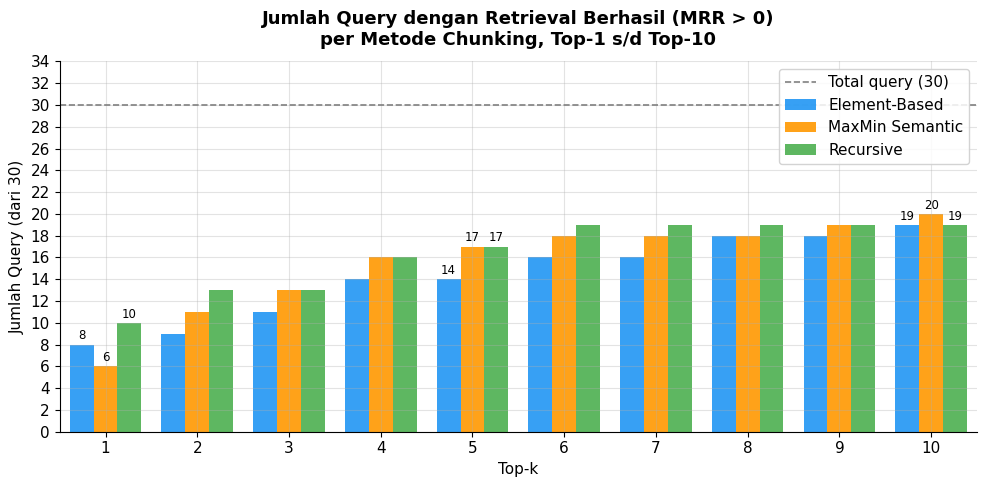

In [3]:
x       = np.arange(1, 11)   # top-k 1..10
width   = 0.26
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(10, 5))

for i, method in enumerate(METHOD_ORDER):
    bars = ax.bar(
        x + offsets[i], hit_df[method], width,
        label=method,
        color=METHOD_COLORS[method], alpha=0.9,
    )
    # Label angka di atas bar di posisi k=1, 5, 10
    for j, bar in enumerate(bars):
        if x[j] in (1, 5, 10):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                str(int(bar.get_height())),
                ha="center", va="bottom", fontsize=8.5,
            )

# Garis batas total query
ax.axhline(total_queries, color="gray", linestyle="--", linewidth=1.2,
           label=f"Total query ({total_queries})")

ax.set_xlabel("Top-k")
ax.set_ylabel("Jumlah Query (dari 30)")
ax.set_title(
    "Jumlah Query dengan Retrieval Berhasil (MRR > 0)\nper Metode Chunking, Top-1 s/d Top-10",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xticks(x)
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0, total_queries + 4)
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax.legend(framealpha=0.85)

fig.tight_layout()
plt.show()

## 4. Simpan PNG

In [4]:
out_path = FIG_DIR / "04_retrieval_hit_count.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Tersimpan: {out_path.resolve()}")

Tersimpan: D:\My Files\Kuliah\SKRIPSI\rag-skripsi\results\final\figures\04_retrieval_hit_count.png


## 5. Interpretasi

- **Top-1:** Recursive paling banyak (10/30), Element-Based 8/30, MaxMin 6/30.
- **Top-5:** Recursive & MaxMin 17/30, Element-Based 14/30.
- **Top-10:** Semua mendekati 19-20/30 — ada ~10 query yang tidak berhasil di-retrieve di semua metode sekalipun di k=10. Ini query dengan chunk yang terlalu granular atau terminologi yang tidak cocok dengan embedder.
- Kurva pertumbuhan paling cepat di k=1→5; setelah k=6 mulai mendatar.